# Predicción de NO₂ mediante XGBoost sin información histórica del contaminante

## Objetivo

Este notebook evalúa la capacidad de predecir la concentración diaria de NO₂ utilizando información meteorológica, temporal y espacial, sin incorporar como variables predictoras las concentraciones históricas del propio contaminante.

El objetivo es estudiar hasta qué punto las condiciones meteorológicas, el calendario y las características de la ubicación permiten explicar y predecir la variabilidad del NO₂ de forma independiente a su persistencia temporal.

El modelo utilizará tres grupos principales de variables:

- **Meteorológicas:** temperatura, humedad, precipitación, presión y viento.
- **Temporales:** condición de día laborable y representación cíclica de la estacionalidad anual.
- **Espaciales:** características reales de las estaciones de calidad del aire, como latitud, longitud, altitud y tipo de estación.

Se excluyen explícitamente los lags de NO₂ (`lag_1`, `lag_2`, `lag_3` y `lag_7`).

Posteriormente, los resultados obtenidos se compararán con el modelo XGBoost que sí incorpora información histórica del contaminante para cuantificar la aportación predictiva de dicha información temporal.

In [1]:
# ============================================================
# IMPORTS
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

## 1. Carga de datos

El dataset principal contiene las observaciones diarias utilizadas para el modelado del NO₂, incluyendo las variables meteorológicas y de calendario previamente preparadas.

Adicionalmente, se utiliza la dimensión de estaciones de calidad del aire generada por la ETL del proyecto. Esta dimensión contiene información descriptiva y espacial de cada estación.

La incorporación de esta información permite representar la ubicación de cada observación mediante características con significado real, en lugar de utilizar directamente el identificador numérico de la estación.

In [2]:
# ============================================================
# RUTAS DEL PROYECTO
# ============================================================

ROOT = Path.cwd()

while not (ROOT / "data").exists():
    ROOT = ROOT.parent

DATA_PATH = (
    ROOT
    / "data"
    / "modeling"
    / "dataset_no2.parquet"
)

ESTACIONES_PATH = (
    ROOT
    / "data"
    / "enriched"
    / "dims"
    / "dim_estaciones_aire.parquet"
)

print("Raíz del proyecto:", ROOT)
print("Dataset:", DATA_PATH)
print("Metadata estaciones:", ESTACIONES_PATH)

Raíz del proyecto: c:\Users\borja\Desktop\Master\TFM
Dataset: c:\Users\borja\Desktop\Master\TFM\data\modeling\dataset_no2.parquet
Metadata estaciones: c:\Users\borja\Desktop\Master\TFM\data\enriched\dims\dim_estaciones_aire.parquet


In [3]:
# ============================================================
# CARGA DE DATOS
# ============================================================

df = pd.read_parquet(DATA_PATH)

estaciones_aire = pd.read_parquet(
    ESTACIONES_PATH
)

print("Dataset NO₂:", df.shape)
print("Metadata estaciones:", estaciones_aire.shape)

print(
    "\nPeriodo:",
    df["fecha"].min(),
    "→",
    df["fecha"].max()
)

display(df.head())

Dataset NO₂: (40040, 24)
Metadata estaciones: (25, 11)

Periodo: 2020-01-08 00:00:00 → 2024-12-31 00:00:00


,fecha,estacion,contaminante_t,es_laborable_madrid_ciudad,direccion_racha_max,humedad_max,humedad_media,humedad_min,insolacion,precipitacion,...,temp_min,viento_racha,viento_velocidad,mes,mes_sin,mes_cos,no2_lag_1,no2_lag_2,no2_lag_3,no2_lag_7
0,2020-01-08,8,99.791667,True,90.0,72.0,47.0,27.0,8.8,0.0,...,1.8,3.3,0.3,1,0.5,0.866025,85.130435,60.083333,51.291667,65.666667
1,2020-01-09,8,77.958333,True,300.0,75.0,59.0,49.0,8.6,0.0,...,4.0,9.4,1.1,1,0.5,0.866025,99.791667,85.130435,60.083333,68.083333
2,2020-01-10,8,54.500000,True,40.0,73.0,50.0,37.0,8.9,0.0,...,4.2,9.7,3.3,1,0.5,0.866025,77.958333,99.791667,85.130435,73.458333
3,2020-01-11,8,56.625000,False,50.0,69.0,52.0,38.0,9.2,0.0,...,2.0,6.1,1.4,1,0.5,0.866025,54.500000,77.958333,99.791667,42.347826
4,2020-01-12,8,70.375000,False,170.0,76.0,69.0,56.0,9.1,0.0,...,-0.7,3.1,1.1,1,0.5,0.866025,56.625000,54.500000,77.958333,51.291667


## 2. Incorporación de información espacial

Cada observación del dataset está asociada a una estación de calidad del aire.

El identificador numérico de la estación no se utiliza directamente como variable predictora, ya que constituye únicamente un código identificativo y no representa una magnitud cuantitativa u ordinal.

Utilizar directamente dicho código podría permitir al modelo realizar divisiones numéricas entre identificadores sin que estas relaciones tengan un significado real.

En su lugar, el identificador `estacion` se utiliza únicamente como clave para incorporar características reales de cada estación:

- latitud;
- longitud;
- altitud;
- tipo de estación.

De esta forma, el modelo recibe información sobre el contexto espacial y funcional de la estación sin depender de un identificador arbitrario.

In [4]:
# ============================================================
# SELECCIÓN DE METADATA DE ESTACIONES
# ============================================================

metadata_modelo = estaciones_aire[
    [
        "ESTACION",
        "LATITUD_G",
        "LONGITUD_G",
        "ALTITUD",
        "TIPO_ESTACION"
    ]
].copy()

metadata_modelo = metadata_modelo.rename(
    columns={
        "ESTACION": "estacion"
    }
)

display(metadata_modelo.head())

,estacion,LATITUD_G,LONGITUD_G,ALTITUD,TIPO_ESTACION
0,8,40.42167,-3.68222,672,TRAFICO
1,16,40.44000,-3.63917,698,FONDO
2,17,40.34694,-3.70500,593,FONDO
3,18,40.39472,-3.73194,625,FONDO
4,24,40.42000,-3.74917,645,FONDO


In [5]:
# ============================================================
# JOIN CON LA METADATA DE ESTACIONES
# ============================================================

filas_antes = len(df)

df = df.merge(
    metadata_modelo,
    on="estacion",
    how="left",
    validate="many_to_one"
)

filas_despues = len(df)

print("Filas antes del join:", filas_antes)
print("Filas después del join:", filas_despues)

display(
    df[
        [
            "estacion",
            "LATITUD_G",
            "LONGITUD_G",
            "ALTITUD",
            "TIPO_ESTACION"
        ]
    ].head()
)

Filas antes del join: 40040
Filas después del join: 40040


,estacion,LATITUD_G,LONGITUD_G,ALTITUD,TIPO_ESTACION
0,8,40.42167,-3.68222,672,TRAFICO
1,8,40.42167,-3.68222,672,TRAFICO
2,8,40.42167,-3.68222,672,TRAFICO
3,8,40.42167,-3.68222,672,TRAFICO
4,8,40.42167,-3.68222,672,TRAFICO


In [6]:
# ============================================================
# VALIDACIÓN DEL JOIN
# ============================================================

columnas_metadata = [
    "LATITUD_G",
    "LONGITUD_G",
    "ALTITUD",
    "TIPO_ESTACION"
]

print("Nulos en metadata incorporada:")
display(
    df[columnas_metadata]
    .isna()
    .sum()
)

assert filas_antes == filas_despues

assert (
    df[columnas_metadata]
    .isna()
    .sum()
    .sum()
    == 0
)

print("✓ Join realizado correctamente.")
print("✓ No se han añadido ni eliminado observaciones.")
print("✓ Todas las estaciones disponen de metadata.")


Nulos en metadata incorporada:


LATITUD_G        0
LONGITUD_G       0
ALTITUD          0
TIPO_ESTACION    0
dtype: int64

✓ Join realizado correctamente.
✓ No se han añadido ni eliminado observaciones.
✓ Todas las estaciones disponen de metadata.


## 3. Codificación del tipo de estación

La variable `TIPO_ESTACION` es categórica y describe la función o naturaleza de cada estación de calidad del aire.

No se asignan valores numéricos ordinales a sus categorías, ya que no existe un orden cuantitativo entre ellas.

En su lugar, se aplica una codificación *one-hot*, generando una variable binaria independiente para cada categoría. De esta forma, XGBoost puede utilizar esta información sin introducir relaciones ordinales artificiales.

In [7]:
# ============================================================
# TIPOS DE ESTACIÓN
# ============================================================

display(
    df["TIPO_ESTACION"]
    .value_counts()
    .rename("observaciones")
)


TIPO_ESTACION
FONDO      27300
TRAFICO    12740
Name: observaciones, dtype: int64

In [8]:
# ============================================================
# ONE-HOT ENCODING
# ============================================================

df_modelo = pd.get_dummies(
    df,
    columns=["TIPO_ESTACION"],
    prefix="tipo_estacion",
    dtype=int
)

columnas_tipo_estacion = [
    columna
    for columna in df_modelo.columns
    if columna.startswith("tipo_estacion_")
]

print("Variables creadas:")

for columna in columnas_tipo_estacion:
    print("-", columna)

Variables creadas:
- tipo_estacion_FONDO
- tipo_estacion_TRAFICO


## 4. Definición de variables predictoras

Las variables utilizadas por el modelo se dividen en tres grupos.

### Variables meteorológicas

Representan las condiciones atmosféricas correspondientes al día para el que se realiza la predicción.

### Variables temporales

Incluyen la condición de día laborable y una representación cíclica del mes mediante seno y coseno, permitiendo modelar la estacionalidad anual sin introducir discontinuidades artificiales entre diciembre y enero.

### Variables espaciales

La ubicación de la estación se representa mediante latitud, longitud y altitud. Además, se incorpora el tipo de estación mediante variables binarias.

El identificador numérico de estación no se utiliza como predictor.

Tampoco se incluyen concentraciones históricas de NO₂, ya que el objetivo de este experimento es evaluar la capacidad predictiva de las variables externas al propio contaminante.

In [9]:
# ============================================================
# DEFINICIÓN DE FEATURES Y TARGET
# ============================================================

TARGET = "contaminante_t"

features_meteo = [
    "direccion_racha_max",
    "humedad_media",
    "precipitacion",
    "presion_max",
    "presion_min",
    "temp_max",
    "temp_media",
    "temp_min",
    "viento_racha",
    "viento_velocidad",
]

features_calendario = [
    "es_laborable_madrid_ciudad",
    "mes_sin",
    "mes_cos",
]

features_espaciales = [
    "LATITUD_G",
    "LONGITUD_G",
    "ALTITUD",
]

FEATURES = (
    features_meteo
    + features_calendario
    + features_espaciales
    + columnas_tipo_estacion
)

X = df_modelo[FEATURES].copy()
y = df_modelo[TARGET].copy()

print("Número de observaciones:", len(X))
print("Número de features:", len(FEATURES))

print("\nFeatures utilizadas:")

for feature in FEATURES:
    print("-", feature)

print("\nNulos en X:", X.isna().sum().sum())
print("Nulos en y:", y.isna().sum())

Número de observaciones: 40040
Número de features: 18

Features utilizadas:
- direccion_racha_max
- humedad_media
- precipitacion
- presion_max
- presion_min
- temp_max
- temp_media
- temp_min
- viento_racha
- viento_velocidad
- es_laborable_madrid_ciudad
- mes_sin
- mes_cos
- LATITUD_G
- LONGITUD_G
- ALTITUD
- tipo_estacion_FONDO
- tipo_estacion_TRAFICO

Nulos en X: 0
Nulos en y: 0


## 5. División temporal

La división de los datos se realiza respetando estrictamente su orden temporal.

Se utilizan:

- **2020-2022:** entrenamiento.
- **2023:** validación y selección del modelo.
- **2024:** test final.

El conjunto de test permanece reservado durante el desarrollo y no se utiliza para seleccionar hiperparámetros ni tomar decisiones sobre la configuración del modelo.

Esta misma división temporal permite posteriormente comparar los resultados con el modelo XGBoost que incorpora lags del NO₂ bajo condiciones equivalentes de evaluación.


In [10]:
# ============================================================
# SPLIT TEMPORAL
# ============================================================

train_mask = (
    df_modelo["fecha"] < "2023-01-01"
)

val_mask = (
    (df_modelo["fecha"] >= "2023-01-01")
    & (df_modelo["fecha"] < "2024-01-01")
)

test_mask = (
    df_modelo["fecha"] >= "2024-01-01"
)


X_train = X.loc[train_mask].copy()
y_train = y.loc[train_mask].copy()

X_val = X.loc[val_mask].copy()
y_val = y.loc[val_mask].copy()

X_test = X.loc[test_mask].copy()
y_test = y.loc[test_mask].copy()


print("TRAIN")
print(
    df_modelo.loc[train_mask, "fecha"].min(),
    "→",
    df_modelo.loc[train_mask, "fecha"].max()
)
print("Observaciones:", len(X_train))


print("\nVALIDATION")
print(
    df_modelo.loc[val_mask, "fecha"].min(),
    "→",
    df_modelo.loc[val_mask, "fecha"].max()
)
print("Observaciones:", len(X_val))


print("\nTEST")
print(
    df_modelo.loc[test_mask, "fecha"].min(),
    "→",
    df_modelo.loc[test_mask, "fecha"].max()
)
print("Observaciones:", len(X_test))


TRAIN
2020-01-08 00:00:00 → 2022-12-31 00:00:00
Observaciones: 23958

VALIDATION
2023-01-01 00:00:00 → 2023-12-31 00:00:00
Observaciones: 8030

TEST
2024-01-01 00:00:00 → 2024-12-31 00:00:00
Observaciones: 8052


## 6. Modelo XGBoost inicial

Como primera aproximación se entrena un modelo XGBoost con una configuración razonable de hiperparámetros, sin realizar todavía ningún proceso de optimización.

Este modelo permite establecer un rendimiento inicial utilizando exclusivamente:

- variables meteorológicas;
- variables temporales;
- características espaciales y funcionales de las estaciones.

La evaluación se realiza sobre el conjunto de validación de 2023. El conjunto de test de 2024 permanece reservado y no se utiliza durante esta fase.

Los resultados obtenidos servirán como referencia antes de realizar la optimización de hiperparámetros.

In [11]:
# ============================================================
# XGBOOST INICIAL
# ============================================================

modelo_inicial = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

modelo_inicial.fit(
    X_train,
    y_train
)

print("✓ Modelo entrenado correctamente.")

✓ Modelo entrenado correctamente.


In [12]:
# ============================================================
# PREDICCIÓN SOBRE VALIDATION 2023
# ============================================================

y_pred_val = modelo_inicial.predict(X_val)

print("Predicciones realizadas:", len(y_pred_val))

Predicciones realizadas: 8030


In [13]:
# ============================================================
# MÉTRICAS DE VALIDACIÓN
# ============================================================

mae_val = mean_absolute_error(
    y_val,
    y_pred_val
)

rmse_val = np.sqrt(
    mean_squared_error(
        y_val,
        y_pred_val
    )
)

r2_val = r2_score(
    y_val,
    y_pred_val
)

print("XGBOOST SIN LAGS - VALIDATION 2023")
print("-----------------------------------")
print(f"MAE:  {mae_val:.3f}")
print(f"RMSE: {rmse_val:.3f}")
print(f"R²:   {r2_val:.3f}")

XGBOOST SIN LAGS - VALIDATION 2023
-----------------------------------
MAE:  6.291
RMSE: 8.215
R²:   0.721


### Resultados del modelo inicial

El modelo inicial sin información histórica del contaminante obtiene sobre el conjunto de validación de 2023:

- **MAE:** 6.291 µg/m³
- **RMSE:** 8.215 µg/m³
- **R²:** 0.721

Estos resultados muestran que el modelo es capaz de capturar una parte considerable de la variabilidad del NO₂ utilizando exclusivamente información meteorológica, temporal y espacial.

La incorporación de características reales de las estaciones permite representar las diferencias espaciales entre puntos de medida sin utilizar directamente su identificador numérico.

El resultado constituye la referencia inicial antes de realizar la optimización de hiperparámetros.

In [14]:
# ============================================================
# IMPORTANCIA PRELIMINAR DE VARIABLES
# ============================================================

importancias = pd.DataFrame({
    "feature": FEATURES,
    "importancia": modelo_inicial.feature_importances_
})

importancias = (
    importancias
    .sort_values("importancia", ascending=False)
    .reset_index(drop=True)
)

display(importancias)

,feature,importancia
0,viento_racha,0.184693
1,mes_cos,0.177392
2,es_laborable_madrid_ciudad,0.130445
3,viento_velocidad,0.093970
4,tipo_estacion_FONDO,0.056287
5,tipo_estacion_TRAFICO,0.049493
6,LONGITUD_G,0.045842
7,ALTITUD,0.045547
8,temp_min,0.042175
9,temp_media,0.038541


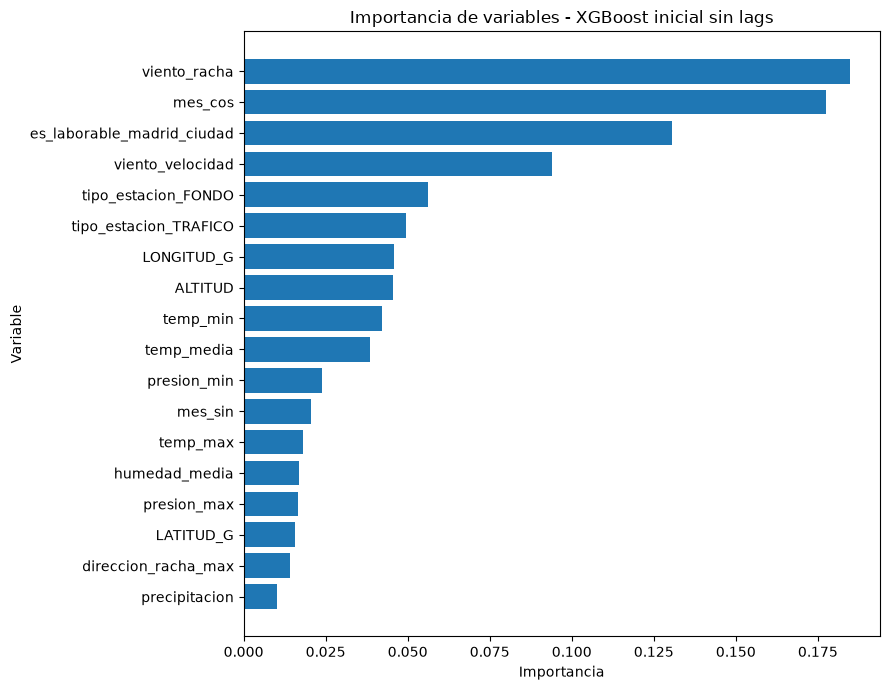

In [15]:
# ============================================================
# VISUALIZACIÓN DE IMPORTANCIA DE VARIABLES
# ============================================================

plt.figure(figsize=(9, 7))

plt.barh(
    importancias["feature"][::-1],
    importancias["importancia"][::-1]
)

plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Importancia de variables - XGBoost inicial sin lags")

plt.tight_layout()
plt.show()

### Interpretación preliminar de la importancia de variables

La importancia interna de XGBoost muestra que las variables más utilizadas por el modelo están relacionadas principalmente con el viento, la estacionalidad anual y la condición de día laborable.

La información asociada a la ubicación también presenta una contribución relevante. En particular, el tipo de estación, la longitud y la altitud aparecen entre las variables utilizadas por el modelo para diferenciar el comportamiento espacial del NO₂.

Estos resultados respaldan la utilización de características reales de las estaciones frente al identificador numérico de estación, permitiendo incorporar información espacial y funcional con significado interpretable.

Las importancias mostradas corresponden a medidas internas de XGBoost y no deben interpretarse como porcentajes de variabilidad explicada ni como relaciones causales. La interpretación posterior mediante SHAP permitirá analizar con mayor detalle la dirección y magnitud de la contribución de cada variable a las predicciones.

## 7. Optimización de hiperparámetros

Tras evaluar el modelo inicial, se realiza una optimización de hiperparámetros con el objetivo de mejorar su capacidad predictiva.

Debido a la naturaleza temporal del problema, la validación cruzada no se realiza mediante particiones aleatorias. Los datos se dividen en bloques temporales sucesivos, garantizando que las observaciones utilizadas para validar cada configuración correspondan siempre a fechas posteriores a las utilizadas para su entrenamiento.

Además, dado que existen múltiples observaciones para una misma fecha correspondientes a diferentes estaciones, las particiones se construyen utilizando fechas completas. De esta forma, todas las estaciones correspondientes a un mismo día permanecen dentro del mismo conjunto.

El conjunto de test correspondiente a 2024 continúa completamente reservado durante esta fase.

In [16]:
# ============================================================
# CONSTRUCCIÓN DE FOLDS TEMPORALES POR FECHA
# ============================================================

fechas_train = df_modelo.loc[train_mask, "fecha"].reset_index(drop=True)

fechas_unicas = np.sort(
    fechas_train.unique()
)

print("Fechas únicas en train:", len(fechas_unicas))
print("Periodo:", fechas_unicas[0], "→", fechas_unicas[-1])

Fechas únicas en train: 1089
Periodo: 2020-01-08T00:00:00.000000 → 2022-12-31T00:00:00.000000


In [17]:
# ============================================================
# VALIDACIÓN TEMPORAL EXPANSIVA
# ============================================================

from sklearn.model_selection import TimeSeriesSplit

tscv_fechas = TimeSeriesSplit(n_splits=4)

cv_temporal = []

for fold, (train_dates_idx, val_dates_idx) in enumerate(
    tscv_fechas.split(fechas_unicas),
    start=1
):
    fechas_fold_train = fechas_unicas[train_dates_idx]
    fechas_fold_val = fechas_unicas[val_dates_idx]

    idx_train = np.where(
        fechas_train.isin(fechas_fold_train)
    )[0]

    idx_val = np.where(
        fechas_train.isin(fechas_fold_val)
    )[0]

    cv_temporal.append(
        (idx_train, idx_val)
    )

    print(f"\nFOLD {fold}")
    print(
        "Train:",
        fechas_fold_train[0],
        "→",
        fechas_fold_train[-1],
        f"({len(idx_train)} observaciones)"
    )
    print(
        "Validation:",
        fechas_fold_val[0],
        "→",
        fechas_fold_val[-1],
        f"({len(idx_val)} observaciones)"
    )


FOLD 1
Train: 2020-01-08T00:00:00.000000 → 2020-08-15T00:00:00.000000 (4862 observaciones)
Validation: 2020-08-16T00:00:00.000000 → 2021-03-20T00:00:00.000000 (4774 observaciones)

FOLD 2
Train: 2020-01-08T00:00:00.000000 → 2021-03-20T00:00:00.000000 (9636 observaciones)
Validation: 2021-03-21T00:00:00.000000 → 2021-10-23T00:00:00.000000 (4774 observaciones)

FOLD 3
Train: 2020-01-08T00:00:00.000000 → 2021-10-23T00:00:00.000000 (14410 observaciones)
Validation: 2021-10-24T00:00:00.000000 → 2022-05-28T00:00:00.000000 (4774 observaciones)

FOLD 4
Train: 2020-01-08T00:00:00.000000 → 2022-05-28T00:00:00.000000 (19184 observaciones)
Validation: 2022-05-29T00:00:00.000000 → 2022-12-31T00:00:00.000000 (4774 observaciones)


### Búsqueda de hiperparámetros

Se utiliza `RandomizedSearchCV` para explorar diferentes combinaciones de los principales hiperparámetros de XGBoost.

La métrica utilizada para seleccionar las configuraciones es el **MAE**, al proporcionar una interpretación directa del error medio de predicción en las mismas unidades que la concentración de NO₂.

La búsqueda se realiza exclusivamente sobre el conjunto de entrenamiento (2020–2022), utilizando las particiones temporales definidas anteriormente.

In [18]:
# ============================================================
# RANDOMIZED SEARCH
# ============================================================

from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    "n_estimators": [300, 500, 700, 900, 1200],
    "max_depth": [3, 4, 5, 6, 7, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.05, 0.1, 0.2],
    "reg_alpha": [0, 0.01, 0.1, 0.5],
    "reg_lambda": [0.5, 1, 2, 5]
}

modelo_base = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=modelo_base,
    param_distributions=param_distributions,
    n_iter=40,
    scoring="neg_mean_absolute_error",
    cv=cv_temporal,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(
    X_train.reset_index(drop=True),
    y_train.reset_index(drop=True)
)

print("\nMejores hiperparámetros:")
print(random_search.best_params_)

print(
    "\nMAE medio en CV temporal:",
    -random_search.best_score_
)

Fitting 4 folds for each of 40 candidates, totalling 160 fits

Mejores hiperparámetros:
{'subsample': 0.8, 'reg_lambda': 5, 'reg_alpha': 0.5, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.03, 'gamma': 0.2, 'colsample_bytree': 0.7}

MAE medio en CV temporal: 6.997704796758033


## 8. Evaluación del modelo optimizado sobre validación

Una vez seleccionada la mejor configuración mediante validación cruzada temporal sobre el periodo 2020–2022, se evalúa el modelo optimizado sobre el conjunto de validación externo correspondiente a 2023.

Este periodo no ha intervenido en la búsqueda de hiperparámetros, por lo que permite comprobar si la configuración seleccionada mantiene su capacidad predictiva sobre datos temporalmente posteriores.

Los resultados se comparan con el modelo inicial para determinar si la optimización proporciona una mejora real.

In [19]:
# ============================================================
# MEJOR MODELO OBTENIDO EN EL TUNING
# ============================================================

modelo_optimizado = random_search.best_estimator_

print("Mejores hiperparámetros:")
for parametro, valor in random_search.best_params_.items():
    print(f"- {parametro}: {valor}")

print(
    f"\nMAE medio CV temporal: "
    f"{-random_search.best_score_:.3f}"
)

Mejores hiperparámetros:
- subsample: 0.8
- reg_lambda: 5
- reg_alpha: 0.5
- n_estimators: 300
- min_child_weight: 5
- max_depth: 8
- learning_rate: 0.03
- gamma: 0.2
- colsample_bytree: 0.7

MAE medio CV temporal: 6.998


In [20]:
# ============================================================
# EVALUACIÓN EN VALIDATION 2023
# ============================================================

y_pred_val_opt = modelo_optimizado.predict(X_val)

mae_val_opt = mean_absolute_error(
    y_val,
    y_pred_val_opt
)

rmse_val_opt = np.sqrt(
    mean_squared_error(
        y_val,
        y_pred_val_opt
    )
)

r2_val_opt = r2_score(
    y_val,
    y_pred_val_opt
)

print("XGBOOST OPTIMIZADO - VALIDATION 2023")
print("-------------------------------------")
print(f"MAE:  {mae_val_opt:.3f}")
print(f"RMSE: {rmse_val_opt:.3f}")
print(f"R²:   {r2_val_opt:.3f}")

XGBOOST OPTIMIZADO - VALIDATION 2023
-------------------------------------
MAE:  6.250
RMSE: 8.175
R²:   0.724


### Resultado de la optimización

El modelo optimizado obtiene sobre el conjunto de validación de 2023 un **MAE de 6.250 µg/m³**, un **RMSE de 8.175 µg/m³** y un **R² de 0.724**.

Respecto al modelo inicial, la optimización produce una mejora moderada pero consistente en las tres métricas evaluadas. El MAE disminuye de 6.291 a 6.250 µg/m³, mientras que el R² aumenta de 0.721 a 0.724.

Aunque la magnitud de la mejora es reducida, la configuración optimizada fue seleccionada exclusivamente mediante validación cruzada temporal sobre el periodo 2020–2022 y posteriormente evaluada sobre 2023. Por tanto, se selecciona esta configuración como modelo definitivo para el experimento sin lags.

## 9. Entrenamiento definitivo y evaluación sobre test

Una vez seleccionada la configuración final del modelo, se combinan los conjuntos de entrenamiento y validación para aprovechar toda la información disponible anterior al periodo de test.

El modelo definitivo se entrena, por tanto, utilizando observaciones correspondientes al periodo **2020–2023**.

Finalmente, se evalúa una única vez sobre **2024**, periodo que se ha mantenido completamente aislado durante el desarrollo y la selección de hiperparámetros.

In [21]:
# ============================================================
# TRAIN DEFINITIVO: 2020-2023
# ============================================================

train_final_mask = (
    df_modelo["fecha"] < "2024-01-01"
)

X_train_final = X.loc[train_final_mask].copy()
y_train_final = y.loc[train_final_mask].copy()

print(
    "Periodo train definitivo:",
    df_modelo.loc[train_final_mask, "fecha"].min(),
    "→",
    df_modelo.loc[train_final_mask, "fecha"].max()
)

print("Observaciones train definitivo:", len(X_train_final))
print("Observaciones test:", len(X_test))

Periodo train definitivo: 2020-01-08 00:00:00 → 2023-12-31 00:00:00
Observaciones train definitivo: 31988
Observaciones test: 8052


In [22]:
# ============================================================
# REENTRENAMIENTO DEL MODELO DEFINITIVO
# ============================================================

mejores_params = random_search.best_params_.copy()

modelo_final = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    **mejores_params
)

modelo_final.fit(
    X_train_final,
    y_train_final
)

print("✓ Modelo definitivo entrenado con datos 2020-2023.")

✓ Modelo definitivo entrenado con datos 2020-2023.


In [23]:
# ============================================================
# EVALUACIÓN FINAL - TEST 2024
# ============================================================

y_pred_test = modelo_final.predict(X_test)

mae_test = mean_absolute_error(
    y_test,
    y_pred_test
)

rmse_test = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_test
    )
)

r2_test = r2_score(
    y_test,
    y_pred_test
)

print("RESULTADOS FINALES - TEST 2024")
print("--------------------------------")
print(f"MAE:  {mae_test:.3f}")
print(f"RMSE: {rmse_test:.3f}")
print(f"R²:   {r2_test:.3f}")

RESULTADOS FINALES - TEST 2024
--------------------------------
MAE:  6.243
RMSE: 7.953
R²:   0.666


### Resultados sobre el conjunto de test

El modelo definitivo obtiene sobre el conjunto de test de 2024:

- **MAE:** 6.243 µg/m³
- **RMSE:** 7.953 µg/m³
- **R²:** 0.666

El MAE y el RMSE se mantienen muy próximos a los obtenidos durante la validación de 2023, lo que indica una estabilidad razonable del error predictivo sobre datos temporalmente posteriores.

El R² disminuye respecto al obtenido en validación (0.724). Esta diferencia no implica necesariamente un aumento del error de predicción, ya que tanto el MAE como el RMSE se mantienen estables. El R² depende también de la variabilidad de la variable objetivo en cada periodo, por lo que resulta conveniente analizar posteriormente las diferencias en la distribución del NO₂ entre 2023 y 2024.

In [24]:
# ============================================================
# COMPARACIÓN DE LA DISTRIBUCIÓN DEL TARGET: 2023 VS 2024
# ============================================================

comparacion_target = pd.DataFrame({
    "2023_validation": [
        y_val.mean(),
        y_val.std(),
        y_val.min(),
        y_val.median(),
        y_val.max()
    ],
    "2024_test": [
        y_test.mean(),
        y_test.std(),
        y_test.min(),
        y_test.median(),
        y_test.max()
    ]
}, index=[
    "Media",
    "Desviación estándar",
    "Mínimo",
    "Mediana",
    "Máximo"
])

display(comparacion_target.round(3))

,2023_validation,2024_test
Media,27.458,22.969
Desviación estándar,15.562,13.763
Mínimo,1.458,1.292
Mediana,24.125,19.500
Máximo,99.286,88.417


### Resultados sobre el conjunto de test

El modelo definitivo obtiene sobre el conjunto de test de 2024 un **MAE de 6.243 µg/m³**, un **RMSE de 7.953 µg/m³** y un **R² de 0.666**.

El MAE y el RMSE se mantienen muy próximos a los obtenidos durante la validación de 2023 (6.250 y 8.175 µg/m³, respectivamente), mostrando una estabilidad elevada del error predictivo sobre datos temporalmente posteriores.

El R² disminuye de 0.724 en validación a 0.666 en test. Sin embargo, el análisis de la variable objetivo muestra que las concentraciones de NO₂ presentan una menor variabilidad en 2024: la desviación estándar disminuye de 15.562 a 13.763 µg/m³. Además, la concentración media disminuye de 27.458 a 22.969 µg/m³.

Dado que el R² mide el error del modelo en relación con la variabilidad de la variable objetivo, esta menor dispersión contribuye a explicar la reducción observada en R², pese a mantenerse estable el error absoluto.

En conjunto, los resultados indican que el modelo conserva una capacidad predictiva estable al aplicarse sobre un periodo temporal no utilizado durante su desarrollo.

## 10. Análisis de las predicciones sobre el conjunto de test

Una vez evaluado el rendimiento global del modelo, se analiza gráficamente su comportamiento sobre el conjunto de test de 2024.

El objetivo es estudiar la correspondencia entre las concentraciones observadas y predichas, así como identificar posibles patrones sistemáticos de error que no quedan reflejados únicamente mediante las métricas agregadas.

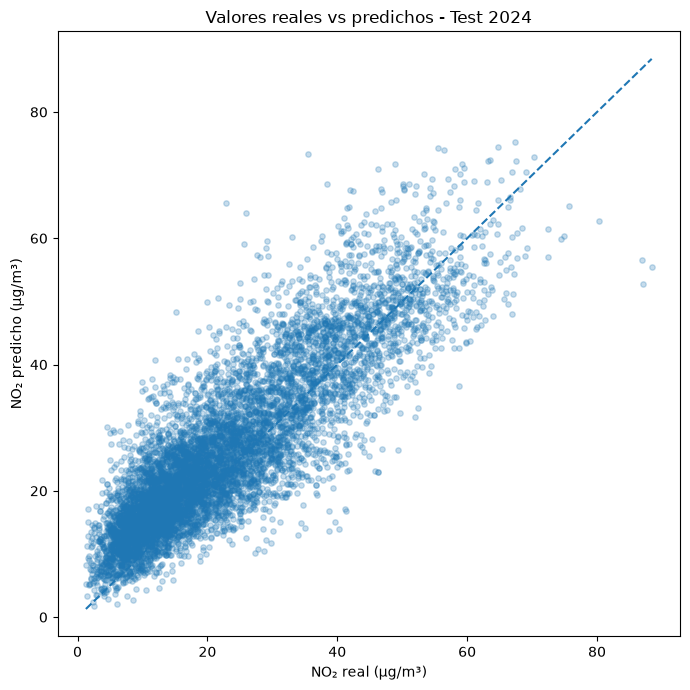

In [25]:
# ============================================================
# VALORES REALES VS PREDICHOS
# ============================================================

plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    y_pred_test,
    alpha=0.25,
    s=15
)

limite_min = min(y_test.min(), y_pred_test.min())
limite_max = max(y_test.max(), y_pred_test.max())

plt.plot(
    [limite_min, limite_max],
    [limite_min, limite_max],
    linestyle="--"
)

plt.xlabel("NO₂ real (µg/m³)")
plt.ylabel("NO₂ predicho (µg/m³)")
plt.title("Valores reales vs predichos - Test 2024")

plt.tight_layout()
plt.show()

### Interpretación

Las predicciones muestran una relación clara con los valores observados, indicando que el modelo reproduce adecuadamente el patrón general de las concentraciones de NO₂ en el conjunto de test de 2024.

Se observa, no obstante, cierta tendencia de las predicciones hacia valores intermedios. Para concentraciones bajas aparecen numerosos casos de sobreestimación, mientras que en los niveles más elevados se aprecia una mayor tendencia a la infraestimación.

Este comportamiento debe interpretarse teniendo en cuenta el cambio observado en la distribución del NO₂ entre los periodos de validación y test. En 2024, la concentración media disminuye de 27.458 a 22.969 µg/m³ y la mediana de 24.125 a 19.500 µg/m³, reflejando un nivel general de contaminación inferior al observado en 2023.

Por tanto, parte de las diferencias observadas podría estar relacionada con este cambio temporal en la distribución del contaminante. Sin embargo, la posible existencia de un sesgo sistemático y la mayor dificultad para predecir concentraciones extremas se estudiarán con mayor detalle mediante el análisis de los residuos.

## 11. Análisis de residuos

Para estudiar con mayor detalle el comportamiento del modelo se analizan los residuos de las predicciones realizadas sobre el conjunto de test de 2024.

El residuo se define como:

\[
e_i = y_i - \hat{y}_i
\]

donde \(y_i\) representa la concentración real y \(\hat{y}_i\) la concentración predicha.

Por tanto:

- un residuo **positivo** indica que el modelo ha infraestimado la concentración;
- un residuo **negativo** indica que el modelo ha sobreestimado la concentración;
- un residuo próximo a **cero** representa una predicción cercana al valor observado.

Este análisis permite detectar posibles sesgos sistemáticos y estudiar si el error del modelo varía en función del nivel de concentración de NO₂.

In [26]:
# ============================================================
# CÁLCULO DE RESIDUOS
# ============================================================

residuos = y_test.to_numpy() - y_pred_test

print(f"Media real 2024:       {y_test.mean():.3f}")
print(f"Media predicha 2024:   {y_pred_test.mean():.3f}")
print(f"Residuo medio:         {residuos.mean():.3f}")
print(f"Mediana residuos:      {np.median(residuos):.3f}")
print(f"Desv. estándar:        {residuos.std():.3f}")

Media real 2024:       22.969
Media predicha 2024:   26.690
Residuo medio:         -3.721
Mediana residuos:      -3.857
Desv. estándar:        7.029


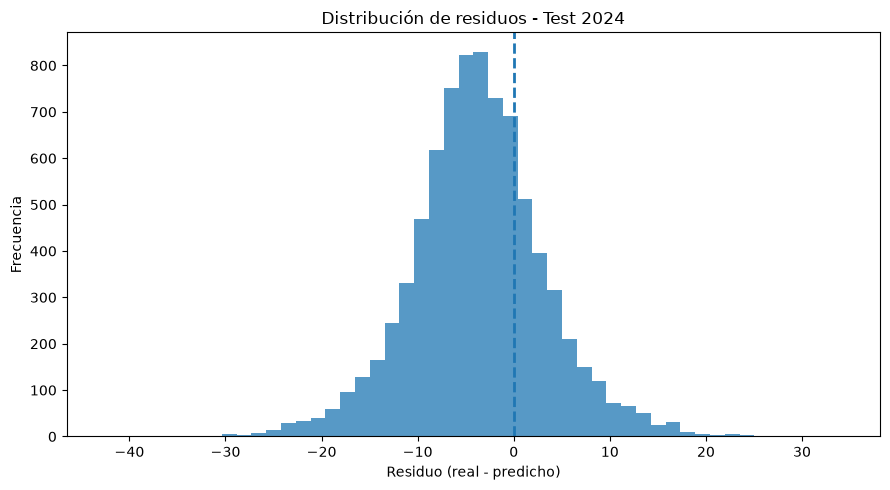

In [27]:
# ============================================================
# DISTRIBUCIÓN DE RESIDUOS
# ============================================================

plt.figure(figsize=(9, 5))

plt.hist(
    residuos,
    bins=50,
    alpha=0.75
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Residuo (real - predicho)")
plt.ylabel("Frecuencia")
plt.title("Distribución de residuos - Test 2024")

plt.tight_layout()
plt.show()

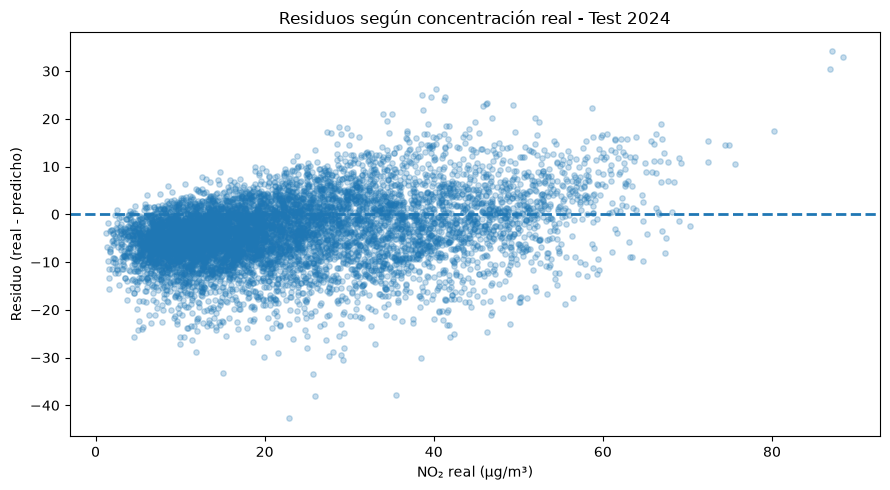

In [28]:
# ============================================================
# RESIDUOS SEGÚN CONCENTRACIÓN REAL
# ============================================================

plt.figure(figsize=(9, 5))

plt.scatter(
    y_test,
    residuos,
    alpha=0.25,
    s=15
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("NO₂ real (µg/m³)")
plt.ylabel("Residuo (real - predicho)")
plt.title("Residuos según concentración real - Test 2024")

plt.tight_layout()
plt.show()

### Interpretación de los residuos

Los residuos presentan una media de **-3.721 µg/m³** y una mediana de **-3.857 µg/m³**, evidenciando un sesgo global de sobreestimación en el conjunto de test de 2024. La concentración media observada es de 22.969 µg/m³, mientras que la media de las predicciones alcanza 26.690 µg/m³.

Este resultado es consistente con el cambio temporal observado en la distribución del NO₂. En 2024, la concentración media es considerablemente inferior a la registrada en 2023, mientras que las predicciones del modelo permanecen en niveles más próximos a los observados durante periodos anteriores. Esto sugiere que parte del descenso general de las concentraciones en 2024 no queda completamente explicado por las variables meteorológicas, temporales y espaciales disponibles.

Además del sesgo global, los residuos muestran una relación con el nivel de concentración. Para valores bajos predominan los residuos negativos, indicando sobreestimación, mientras que para concentraciones elevadas aumentan los residuos positivos, reflejando una tendencia a infraestimar los episodios de mayor concentración.

También se observa un aumento de la dispersión de los residuos conforme aumenta el NO₂, indicando una mayor incertidumbre predictiva para concentraciones elevadas.

En conjunto, el modelo reproduce adecuadamente la variabilidad general del contaminante, pero presenta dos limitaciones principales en 2024: un sesgo global hacia concentraciones superiores a las observadas y una tendencia a suavizar los valores extremos.

## 12. Análisis del error por estación

El modelo se entrena de forma conjunta utilizando observaciones procedentes de diferentes estaciones de calidad del aire. Por ello, las métricas globales pueden ocultar diferencias de rendimiento entre ubicaciones.

Se analiza el comportamiento del modelo de forma desagregada por estación mediante:

- el MAE, como medida de la magnitud media del error;
- el residuo medio, para identificar posibles tendencias sistemáticas de sobreestimación o infraestimación;
- la concentración media observada y predicha.

Este análisis permite determinar si el error y el sesgo observados globalmente en 2024 son homogéneos entre estaciones o se concentran en determinadas ubicaciones.

In [29]:
# ============================================================
# RESULTADOS DE TEST POR ESTACIÓN
# ============================================================

resultados_test = df_modelo.loc[
    test_mask,
    ["fecha", "estacion"]
].copy()

resultados_test["real"] = y_test.to_numpy()
resultados_test["predicho"] = y_pred_test

resultados_test["residuo"] = (
    resultados_test["real"]
    - resultados_test["predicho"]
)

resultados_test["error_abs"] = np.abs(
    resultados_test["residuo"]
)

display(resultados_test.head())

,fecha,estacion,real,predicho,residuo,error_abs
1454,2024-01-01,8,35.000000,39.300686,-4.300686,4.300686
1455,2024-01-02,8,44.142857,62.512672,-18.369815,18.369815
1456,2024-01-03,8,32.916667,37.459805,-4.543138,4.543138
1457,2024-01-04,8,32.666667,46.368191,-13.701524,13.701524
1458,2024-01-05,8,20.666667,27.357943,-6.691276,6.691276


In [30]:
# ============================================================
# MÉTRICAS POR ESTACIÓN
# ============================================================

metricas_estacion = (
    resultados_test
    .groupby("estacion")
    .agg(
        NO2_real_medio=("real", "mean"),
        NO2_predicho_medio=("predicho", "mean"),
        MAE=("error_abs", "mean"),
        residuo_medio=("residuo", "mean"),
        n=("real", "size")
    )
    .sort_values("MAE")
)

display(
    metricas_estacion.round(3)
)

,NO2_real_medio,NO2_predicho_medio,MAE,residuo_medio,n
estacion,,,,,
58,11.467,13.246000,3.434,-1.779,366
24,15.371,16.940001,4.078,-1.568,366
18,25.780,26.253000,5.053,-0.473,366
40,28.019,28.524000,5.108,-0.505,366
59,20.178,21.271999,5.112,-1.094,366
27,28.030,29.032000,5.324,-1.002,366
36,25.694,28.212999,5.356,-2.518,366
57,20.256,23.712999,5.517,-3.457,366
54,26.477,28.226000,5.568,-1.749,366


In [31]:
# ============================================================
# AÑADIR INFORMACIÓN DESCRIPTIVA DE LAS ESTACIONES
# ============================================================

info_estaciones = (
    estaciones_aire[
        ["ESTACION", "NOMBRE", "TIPO_ESTACION"]
    ]
    .drop_duplicates("ESTACION")
    .rename(columns={"ESTACION": "estacion"})
)

metricas_estacion = (
    metricas_estacion
    .reset_index()
    .merge(
        info_estaciones,
        on="estacion",
        how="left",
        validate="one_to_one"
    )
)

metricas_estacion = metricas_estacion[
    [
        "estacion",
        "NOMBRE",
        "TIPO_ESTACION",
        "NO2_real_medio",
        "NO2_predicho_medio",
        "MAE",
        "residuo_medio",
        "n"
    ]
]

display(
    metricas_estacion
    .sort_values("MAE")
    .round(3)
)

,estacion,NOMBRE,TIPO_ESTACION,NO2_real_medio,NO2_predicho_medio,MAE,residuo_medio,n
0,58,EL PARDO,FONDO,11.467,13.246000,3.434,-1.779,366
1,24,CASA DE CAMPO,FONDO,15.371,16.940001,4.078,-1.568,366
2,18,FAROLILLO,FONDO,25.780,26.253000,5.053,-0.473,366
3,40,PUENTE DE VALLECAS,FONDO,28.019,28.524000,5.108,-0.505,366
4,59,JUAN CARLOS I,FONDO,20.178,21.271999,5.112,-1.094,366
5,27,BARAJAS - PUEBLO,FONDO,28.030,29.032000,5.324,-1.002,366
6,36,MORATALAZ,TRAFICO,25.694,28.212999,5.356,-2.518,366
7,57,SANCHINARRO,FONDO,20.256,23.712999,5.517,-3.457,366
8,54,ENSANCHE DE VALLECAS,FONDO,26.477,28.226000,5.568,-1.749,366
9,39,BARRIO DEL PILAR,TRAFICO,25.164,26.969999,5.615,-1.805,366


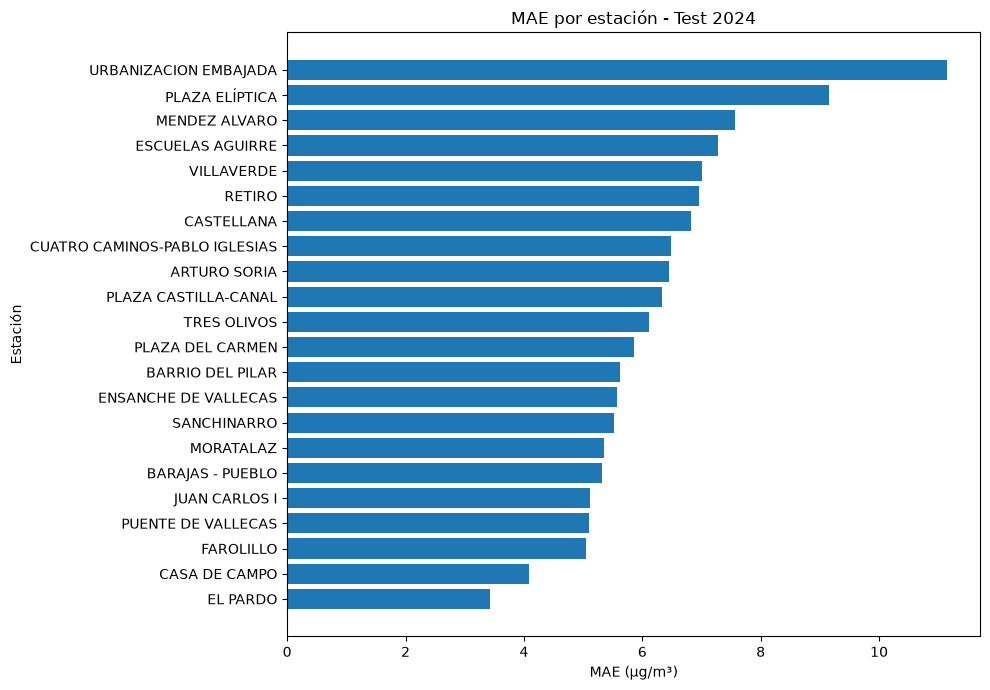

In [32]:
# ============================================================
# MAE POR ESTACIÓN
# ============================================================

plot_mae = (
    metricas_estacion
    .sort_values("MAE")
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_mae["NOMBRE"],
    plot_mae["MAE"]
)

plt.xlabel("MAE (µg/m³)")
plt.ylabel("Estación")
plt.title("MAE por estación - Test 2024")

plt.tight_layout()
plt.show()

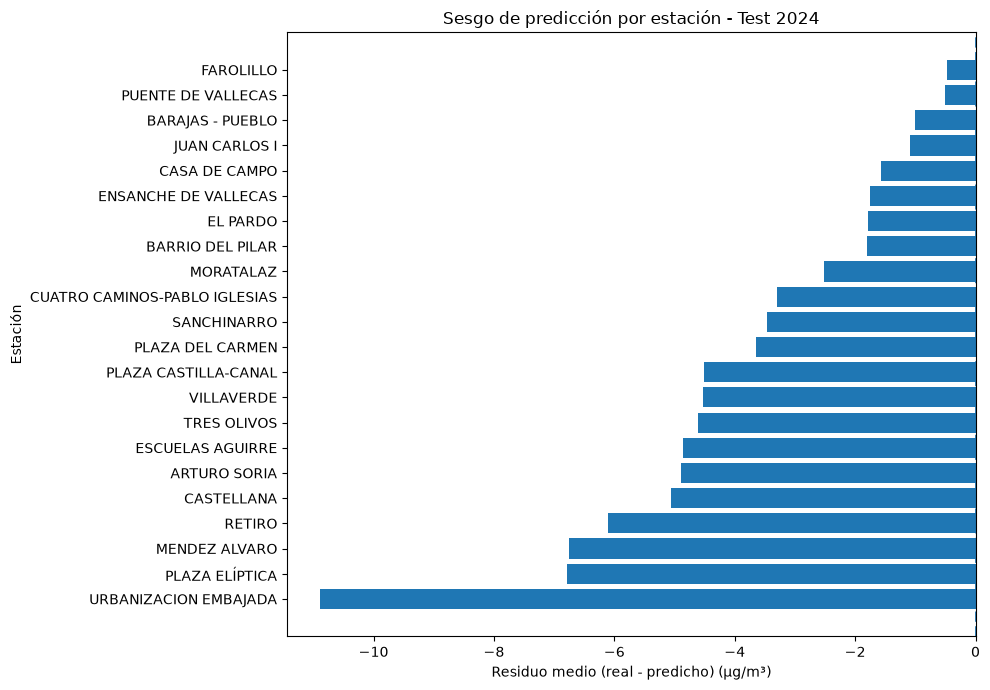

In [33]:
# ============================================================
# RESIDUO MEDIO POR ESTACIÓN
# ============================================================

plot_residuos = (
    metricas_estacion
    .sort_values("residuo_medio")
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_residuos["NOMBRE"],
    plot_residuos["residuo_medio"]
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Residuo medio (real - predicho) (µg/m³)")
plt.ylabel("Estación")
plt.title("Sesgo de predicción por estación - Test 2024")

plt.tight_layout()
plt.show()

### Interpretación del error por estación

El análisis desagregado muestra diferencias relevantes en la capacidad predictiva del modelo entre estaciones.

El MAE varía desde aproximadamente **3.4 µg/m³ en El Pardo** hasta **11.1 µg/m³ en Urbanización Embajada**, indicando que determinadas ubicaciones presentan patrones de NO₂ considerablemente más difíciles de reproducir mediante las variables disponibles.

El análisis del residuo medio revela además un resultado especialmente relevante: **todas las estaciones presentan residuos medios negativos en 2024**. Por tanto, la tendencia global de sobreestimación observada anteriormente no está provocada únicamente por unas pocas estaciones, sino que constituye un patrón generalizado en el conjunto de la red.

La magnitud de este sesgo presenta, no obstante, una elevada heterogeneidad espacial. Algunas estaciones, como Farolillo o Puente de Vallecas, presentan residuos medios próximos a cero, mientras que otras, como Plaza Elíptica, Méndez Álvaro o especialmente Urbanización Embajada, muestran una sobreestimación considerable.

No se observa a priori una separación clara del rendimiento exclusivamente en función del tipo de estación, ya que entre las estaciones con mayor y menor error aparecen tanto estaciones de fondo como de tráfico.

Estos resultados refuerzan la existencia de un cambio temporal general en las concentraciones de NO₂ durante 2024 que el modelo, basado únicamente en meteorología, calendario y características espaciales, no consigue reproducir completamente. Al mismo tiempo, las diferencias entre estaciones indican que existen dinámicas locales que tampoco quedan totalmente representadas mediante las variables espaciales incorporadas.

## 13. Interpretabilidad del modelo mediante SHAP

Una vez evaluada la capacidad predictiva del modelo, se analiza su comportamiento mediante valores SHAP (*SHapley Additive exPlanations*).

SHAP permite cuantificar la contribución de cada variable a las predicciones realizadas por el modelo. Para cada observación, el valor SHAP de una característica indica cuánto contribuye dicha variable a desplazar la predicción respecto al valor base del modelo.

De forma general:

- un valor SHAP **positivo** indica que la variable contribuye a aumentar la concentración de NO₂ predicha;
- un valor SHAP **negativo** indica que contribuye a reducirla;
- cuanto mayor es el valor absoluto de SHAP, mayor es la influencia de esa variable sobre la predicción concreta.

Este análisis permite estudiar no solo qué variables son globalmente importantes, sino también la dirección de su efecto y cómo cambia su influencia según el valor que adopta cada característica.

In [34]:
# ============================================================
# SHAP
# ============================================================

import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [35]:
# ============================================================
# MUESTRA PARA INTERPRETABILIDAD
# ============================================================

n_shap = min(3000, len(X_test))

X_shap = X_test.sample(
    n=n_shap,
    random_state=42
)

print("Observaciones utilizadas para SHAP:", len(X_shap))

Observaciones utilizadas para SHAP: 3000


In [36]:
# ============================================================
# CÁLCULO DE VALORES SHAP
# ============================================================

explainer = shap.TreeExplainer(
    modelo_final
)

shap_values = explainer(
    X_shap
)

print("✓ Valores SHAP calculados.")

✓ Valores SHAP calculados.


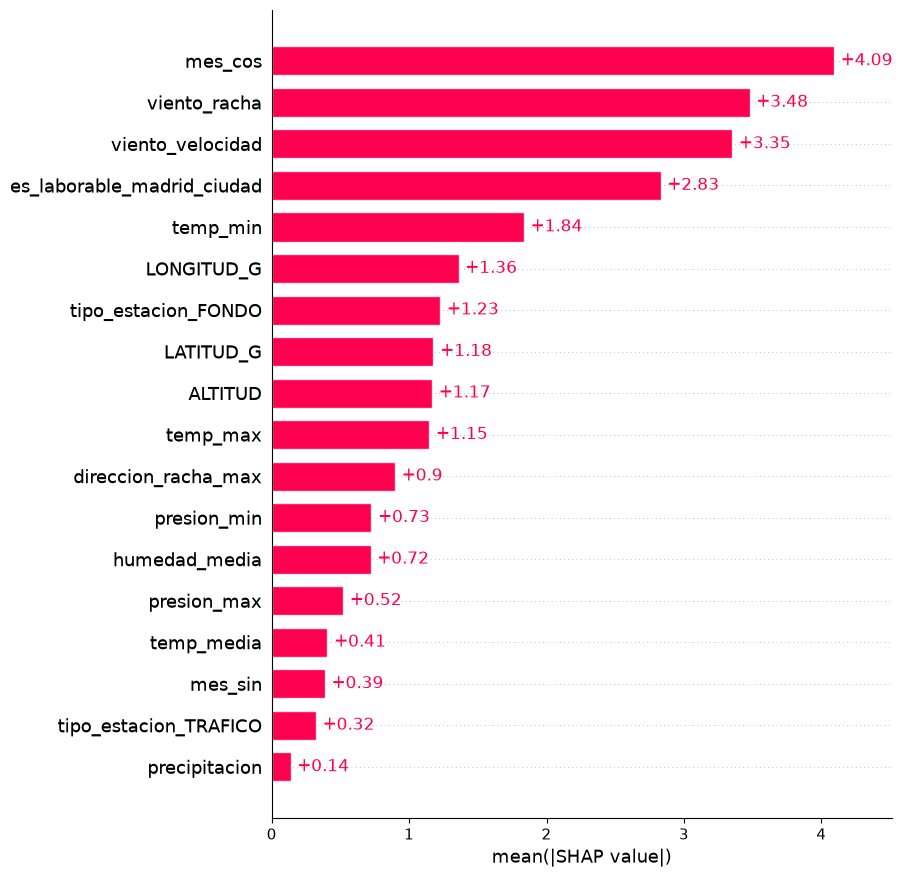

In [37]:
# ============================================================
# IMPORTANCIA GLOBAL SHAP
# ============================================================

shap.plots.bar(
    shap_values,
    max_display=18
)

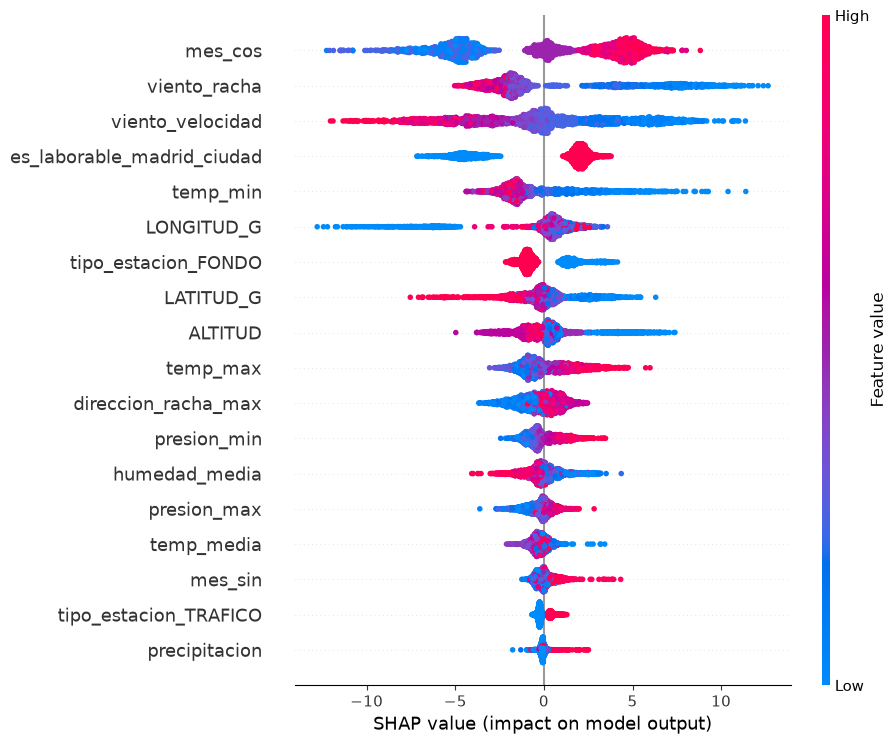

In [38]:
# ============================================================
# SHAP SUMMARY PLOT
# ============================================================

shap.plots.beeswarm(
    shap_values,
    max_display=18
)

### Interpretación global mediante SHAP

El análisis SHAP muestra que la predicción del NO₂ está determinada principalmente por la estacionalidad anual, las condiciones de viento y la condición de día laborable.

La representación cíclica del mes presenta el mayor impacto global, evidenciando una fuerte componente estacional en las concentraciones predichas de NO₂.

Las variables relacionadas con el viento muestran un patrón especialmente claro. Tanto velocidades como rachas elevadas presentan generalmente valores SHAP negativos, mientras que condiciones de viento reducido generan contribuciones positivas. Por tanto, el modelo asocia situaciones de mayor ventilación con menores concentraciones de NO₂ y situaciones de menor viento con concentraciones superiores.

La condición de día laborable también presenta una relación claramente diferenciada. Los días laborables generan contribuciones predominantemente positivas, mientras que los días no laborables contribuyen a reducir las concentraciones predichas.

La información espacial incorporada mediante las características de las estaciones también resulta relevante. Las estaciones clasificadas como de fondo presentan generalmente contribuciones negativas a la predicción, mientras que las estaciones de tráfico muestran una tendencia hacia contribuciones positivas. Las coordenadas y la altitud permiten además capturar diferencias espaciales adicionales entre ubicaciones.

Las variables de temperatura presentan relaciones más complejas. Destaca especialmente la temperatura mínima, cuyos valores reducidos se asocian con contribuciones positivas elevadas. No obstante, dado que se incorporan simultáneamente diferentes variables térmicas y pueden existir interacciones entre ellas, su interpretación individual debe realizarse con cautela.

En conjunto, el análisis SHAP confirma que el modelo utiliza relaciones coherentes entre meteorología, temporalidad y características espaciales para construir sus predicciones. Estas relaciones representan asociaciones aprendidas por el modelo y no deben interpretarse directamente como relaciones causales.

### Análisis de la estacionalidad mensual

Dado que el mes se representa mediante dos variables cíclicas (`mes_sin` y `mes_cos`), la interpretación individual de sus valores SHAP no resulta intuitiva.

Para facilitar la interpretación, se analiza conjuntamente la contribución SHAP de ambas variables en función del mes real del año. De esta forma, es posible estudiar cómo la componente estacional aprendida por el modelo contribuye a aumentar o reducir las predicciones de NO₂ a lo largo del ciclo anual.

In [39]:
# ============================================================
# CONTRIBUCIÓN SHAP DE LA ESTACIONALIDAD POR MES
# ============================================================

# Posición de las variables temporales
idx_mes_sin = X_shap.columns.get_loc("mes_sin")
idx_mes_cos = X_shap.columns.get_loc("mes_cos")

# SHAP conjunto de la representación cíclica del mes
shap_mes = (
    shap_values.values[:, idx_mes_sin]
    + shap_values.values[:, idx_mes_cos]
)

# Recuperamos las fechas de las mismas observaciones de X_shap
fechas_shap = df_modelo.loc[
    X_shap.index,
    "fecha"
]

analisis_mes = pd.DataFrame({
    "mes": fechas_shap.dt.month.to_numpy(),
    "shap_mes": shap_mes
})

display(analisis_mes.head())

,mes,shap_mes
0,7,-5.144905
1,12,4.874023
2,7,-8.651508
3,3,0.624204
4,7,-5.194665


In [40]:
# ============================================================
# SHAP MEDIO POR MES
# ============================================================

shap_por_mes = (
    analisis_mes
    .groupby("mes")["shap_mes"]
    .agg(["mean", "median", "std", "count"])
    .reset_index()
)

nombres_meses = {
    1: "Enero",
    2: "Febrero",
    3: "Marzo",
    4: "Abril",
    5: "Mayo",
    6: "Junio",
    7: "Julio",
    8: "Agosto",
    9: "Septiembre",
    10: "Octubre",
    11: "Noviembre",
    12: "Diciembre"
}

shap_por_mes["nombre_mes"] = (
    shap_por_mes["mes"]
    .map(nombres_meses)
)

display(
    shap_por_mes[
        ["mes", "nombre_mes", "mean", "median", "std", "count"]
    ].round(3)
)

,mes,nombre_mes,mean,median,std,count
0,1,Enero,4.455,4.639,0.936,270
1,2,Febrero,4.610,4.464,1.197,241
2,3,Marzo,0.978,0.802,0.761,260
3,4,Abril,-4.324,-3.809,2.182,259
4,5,Mayo,-5.665,-5.148,1.535,233
5,6,Junio,-5.248,-5.181,1.029,223
6,7,Julio,-5.781,-5.503,1.227,246
7,8,Agosto,-5.743,-5.527,1.251,246
8,9,Septiembre,-0.026,-0.095,0.595,268
9,10,Octubre,3.829,3.824,0.970,258


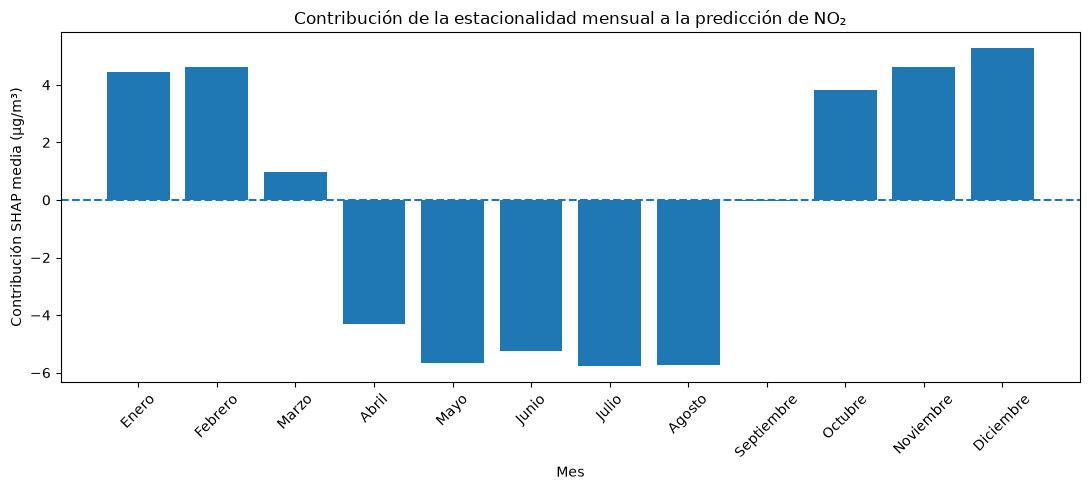

In [41]:
# ============================================================
# CONTRIBUCIÓN ESTACIONAL POR MES
# ============================================================

plt.figure(figsize=(11, 5))

plt.bar(
    shap_por_mes["nombre_mes"],
    shap_por_mes["mean"]
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1.5
)

plt.xlabel("Mes")
plt.ylabel("Contribución SHAP media (µg/m³)")
plt.title("Contribución de la estacionalidad mensual a la predicción de NO₂")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Interpretación de la estacionalidad mensual

La representación cíclica del mes muestra un patrón estacional claramente definido en las predicciones del modelo.

Los meses de invierno presentan contribuciones SHAP positivas elevadas. Enero, febrero, noviembre y diciembre incrementan considerablemente la concentración de NO₂ predicha por el modelo. A partir de marzo esta contribución disminuye y pasa a ser negativa durante la primavera y el verano.

Entre abril y agosto se observan contribuciones negativas especialmente intensas, alcanzándose las mayores reducciones durante los meses estivales. Septiembre representa aproximadamente una zona de transición, mientras que a partir de octubre la contribución estacional vuelve a ser positiva.

Por tanto, el modelo ha aprendido un ciclo anual caracterizado por mayores concentraciones predichas durante los meses fríos y menores concentraciones durante los meses cálidos. Este resultado confirma la elevada importancia atribuida previamente a la componente estacional mediante el análisis SHAP global.

# Comparación final de modelos XGBoost

Una vez desarrolladas y evaluadas las dos variantes del modelo XGBoost, se realiza una comparación final entre:

- **XGBoost sin información histórica**, basado exclusivamente en variables meteorológicas, temporales y espaciales.
- **XGBoost con información histórica**, que incorpora adicionalmente las concentraciones de NO₂ del día anterior (`no2_lag_1`) y de siete días antes (`no2_lag_7`).

Ambos modelos han sido desarrollados siguiendo el mismo esquema temporal de entrenamiento, validación y test, permitiendo realizar una comparación homogénea de su capacidad predictiva.

In [42]:
# ============================================================
# COMPARACIÓN FINAL DE MODELOS XGBOOST
# ============================================================

comparacion_final = pd.DataFrame({
    "Modelo": [
        "Sin lags",
        "Con lag 1 + lag 7"
    ],
    "MAE Validation 2023": [
        6.250,
        5.300
    ],
    "RMSE Validation 2023": [
        8.175,
        6.910
    ],
    "R² Validation 2023": [
        0.724,
        0.803
    ],
    "MAE Test 2024": [
        6.243,
        4.693
    ],
    "RMSE Test 2024": [
        7.953,
        6.042
    ],
    "R² Test 2024": [
        0.666,
        0.807
    ],
    "Sesgo medio Test 2024": [
        -3.721,
        -1.910
    ]
})

display(
    comparacion_final.round(3)
)

,Modelo,MAE Validation 2023,RMSE Validation 2023,R² Validation 2023,MAE Test 2024,RMSE Test 2024,R² Test 2024,Sesgo medio Test 2024
0,Sin lags,6.25,8.175,0.724,6.243,7.953,0.666,-3.721
1,Con lag 1 + lag 7,5.30,6.910,0.803,4.693,6.042,0.807,-1.910


In [43]:
# ============================================================
# MEJORA DEL MODELO CON LAGS
# ============================================================

mejora_mae_2023 = (
    (6.250 - 5.300) / 6.250
) * 100

mejora_rmse_2023 = (
    (8.175 - 6.910) / 8.175
) * 100

mejora_mae_2024 = (
    (6.243 - 4.693) / 6.243
) * 100

mejora_rmse_2024 = (
    (7.953 - 6.042) / 7.953
) * 100

reduccion_sesgo = (
    (abs(-3.721) - abs(-1.910))
    / abs(-3.721)
) * 100

print("MEJORA DEL MODELO CON LAGS")
print("--------------------------------")
print(f"MAE 2023:   {mejora_mae_2023:.1f}%")
print(f"RMSE 2023:  {mejora_rmse_2023:.1f}%")
print(f"MAE 2024:   {mejora_mae_2024:.1f}%")
print(f"RMSE 2024:  {mejora_rmse_2024:.1f}%")
print(f"Sesgo 2024: {reduccion_sesgo:.1f}%")

MEJORA DEL MODELO CON LAGS
--------------------------------
MAE 2023:   15.2%
RMSE 2023:  15.5%
MAE 2024:   24.8%
RMSE 2024:  24.0%
Sesgo 2024: 48.7%


## Conclusiones finales

La comparación entre las dos configuraciones de XGBoost muestra una mejora clara y consistente al incorporar información histórica de las concentraciones de NO₂.

En validación sobre 2023, el modelo con `lag_1` y `lag_7` reduce el MAE de **6.250 a 5.300 µg/m³** y el RMSE de **8.175 a 6.910 µg/m³**, lo que representa mejoras del **15.2 %** y **15.5 %**, respectivamente. Paralelamente, el coeficiente de determinación aumenta de **0.724 a 0.803**.

La mejora resulta todavía más pronunciada sobre el conjunto de test de 2024. El MAE disminuye de **6.243 a 4.693 µg/m³** y el RMSE de **7.953 a 6.042 µg/m³**, equivalentes a reducciones del **24.8 %** y **24.0 %**. El R² aumenta además de **0.666 a 0.807**, mostrando una capacidad considerablemente mayor para explicar la variabilidad de las concentraciones observadas en un periodo no utilizado durante el desarrollo del modelo.

La incorporación de información histórica también reduce de forma importante el sesgo detectado en 2024. El residuo medio pasa de **-3.721 a -1.910 µg/m³**, reduciendo aproximadamente un **48.7 %** la magnitud del sesgo de sobreestimación. El análisis por estación confirma que esta mejora no se concentra únicamente en determinadas localizaciones, sino que se produce de forma generalizada, aunque continúa existiendo cierta tendencia a sobreestimar las concentraciones medias.

Los análisis de importancia de variables y SHAP muestran que `no2_lag_1` se convierte en la principal fuente de información del modelo, evidenciando una fuerte persistencia temporal en las concentraciones de NO₂. `no2_lag_7` presenta un impacto menor, pero aporta información complementaria asociada al comportamiento temporal semanal.

La incorporación de estas variables históricas también reduce considerablemente la dependencia explícita de la componente estacional. El patrón de mayores contribuciones durante otoño e invierno y menores durante primavera y verano se mantiene, pero su magnitud disminuye al disponer el modelo de información directa sobre el estado reciente del contaminante. Las variables meteorológicas, especialmente las relacionadas con el viento, así como la condición de día laborable, continúan aportando información relevante y complementaria.

En conjunto, los resultados muestran que la combinación de **persistencia temporal, meteorología, calendario y características espaciales** proporciona una representación más completa de la dinámica diaria del NO₂. 